Q1. Understanding Feature Distributions (Iris Dataset)

Context: Before training any ML model, we analyze feature distributions.

Dataset: Load Iris dataset from sklearn

Tasks:

1. Extract feature matrix as NumPy array
2. Compute:
Mean
Median
Standard deviation
Variance (for each feature)
3. Identify:
Which feature has highest variability and why it matters in ML
4. Convert any one feature into shape (n,1) and explain why ML models expect this format

In [1]:
from sklearn import datasets
import numpy as np
import pandas as pd

iris_raw_ds = datasets.load_iris(as_frame= True)
iris_raw_df = iris_raw_ds.frame
iris_raw_data = iris_raw_ds.data
print(iris_raw_data)
#1. Extract feature matrix as NumPy array
# Feature matrix as NumPy array
iris_raw_data_np = iris_raw_data.to_numpy()
print(iris_raw_data_np)


     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [

In [2]:
# 2. Compute:
# Mean
# Median
# Standard deviation
# Variance (for each feature)

# print(type(iris_raw_data))
# print(iris_raw_data.columns)
# print(iris_raw_data.shape[0])
# print(iris_raw_data['sepal length (cm)'].count())
for i in iris_raw_data.columns:
    mean = iris_raw_data[i].sum()/iris_raw_data.shape[0]
    print(f"Mean of column {i} is : {mean.round(2)}")
    median = iris_raw_data[i].median()
    print(f"Median of column {i} is : {median}")
    sd = iris_raw_data[i].std()
    print(f"Standard deviation of column {i} is : {round(sd,2)}")
    var = iris_raw_data[i].var()
    print(f"Variance deviation of column {i} is : {round(var,2)}")

    

Mean of column sepal length (cm) is : 5.84
Median of column sepal length (cm) is : 5.8
Standard deviation of column sepal length (cm) is : 0.83
Variance deviation of column sepal length (cm) is : 0.69
Mean of column sepal width (cm) is : 3.06
Median of column sepal width (cm) is : 3.0
Standard deviation of column sepal width (cm) is : 0.44
Variance deviation of column sepal width (cm) is : 0.19
Mean of column petal length (cm) is : 3.76
Median of column petal length (cm) is : 4.35
Standard deviation of column petal length (cm) is : 1.77
Variance deviation of column petal length (cm) is : 3.12
Mean of column petal width (cm) is : 1.2
Median of column petal width (cm) is : 1.3
Standard deviation of column petal width (cm) is : 0.76
Variance deviation of column petal width (cm) is : 0.58


In [ ]:
# 3. Identify: Which feature has highest variability and why it matters in ML
#Ans: Veriance is used to check whether a feature is useful for ML training or not if the veriance is constant, that means if the veriance is zero or near zero then that feature is not useful.
#     Similarly SD shows what is the average distance of a sample from the mean for that feature. So high SD is features are good to concider for ML traning.
#Petal length (cm) has the highest variability in the Iris dataset because it has the largest standard deviation (1.7653) and variance (3.1163). But high variability alone does not guarantee usefulness.
iris_raw_ds = datasets.load_iris(as_frame= True)
X = iris_raw_ds.data # All data with all the features except target
std = X.std()
var = X.var()
mean = X.mean()
# print(f"std: {std}")
# print(f"var: {var}")
# print(f"mean: {mean}")
output = pd.DataFrame({'mean':X.mean(), 'std':std, 'var':var}).sort_values(by = "std", ascending=False)
output_sorted = output.sort_values(by = "std", ascending=False)
print(f"output: {output_sorted}")

max_var_index = np.argmax(var)
feature_names = iris_raw_ds.feature_names


output:                        mean       std       var
petal length (cm)  3.758000  1.765298  3.116278
sepal length (cm)  5.843333  0.828066  0.685694
petal width (cm)   1.199333  0.762238  0.581006
sepal width (cm)   3.057333  0.435866  0.189979


In [ ]:
# 4. Convert any one feature into shape (n,1) and explain why ML models expect this format
## Most algorithms in ML, expects the input features to be in 2D array. This is to keep consistency, avoid ambiguity, because a 1D array can be inferred as "one feature with n samples or one sample with n features."
## Also most of the ML models use matrix operations internally, so 2D array is really convinient.
OneD_array = iris_raw_data["petal length (cm)"] #its a series and its represented as 1D array.
print(OneD_array.shape)
TwoD_array = iris_raw_data[["petal length (cm)"]] # its a dataframe and its rpresented as 2D array.
print(TwoD_array.shape)

feature = iris_raw_ds[:,0]
feature_reshaped = feature.reshape(-1,1)
feature_reshaped.shape


(150,)
(150, 1)


Q2. Data Selection for Model Input

Context: Models are trained on selective features, not full raw data.

Dataset: Iris

Tasks:

1. Extract:
First 100 samples
Only last 2 features
2. Use boolean masking:
Select samples where petal length is greater than dataset mean
3. Count selected samples
4. Explain how this relates to feature-based filtering in ML

In [ ]:
#Extract last two features and first 100 rows  
iris_raw_ds = datasets.load_iris(as_frame= True)
iris_raw_data = iris_raw_ds.data
iris_raw_data_np = iris_raw_data.to_numpy()
print(iris_raw_data_np[:100,-2:])
print(iris_raw_data.iloc[:100,-2:])
print(iris_raw_data_np[:100, -2:].shape) 
print(iris_raw_data.iloc[:100, -2:].shape) 


[[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]
 [1.5 0.2]
 [1.4 0.2]
 [1.7 0.4]
 [1.4 0.3]
 [1.5 0.2]
 [1.4 0.2]
 [1.5 0.1]
 [1.5 0.2]
 [1.6 0.2]
 [1.4 0.1]
 [1.1 0.1]
 [1.2 0.2]
 [1.5 0.4]
 [1.3 0.4]
 [1.4 0.3]
 [1.7 0.3]
 [1.5 0.3]
 [1.7 0.2]
 [1.5 0.4]
 [1.  0.2]
 [1.7 0.5]
 [1.9 0.2]
 [1.6 0.2]
 [1.6 0.4]
 [1.5 0.2]
 [1.4 0.2]
 [1.6 0.2]
 [1.6 0.2]
 [1.5 0.4]
 [1.5 0.1]
 [1.4 0.2]
 [1.5 0.2]
 [1.2 0.2]
 [1.3 0.2]
 [1.4 0.1]
 [1.3 0.2]
 [1.5 0.2]
 [1.3 0.3]
 [1.3 0.3]
 [1.3 0.2]
 [1.6 0.6]
 [1.9 0.4]
 [1.4 0.3]
 [1.6 0.2]
 [1.4 0.2]
 [1.5 0.2]
 [1.4 0.2]
 [4.7 1.4]
 [4.5 1.5]
 [4.9 1.5]
 [4.  1.3]
 [4.6 1.5]
 [4.5 1.3]
 [4.7 1.6]
 [3.3 1. ]
 [4.6 1.3]
 [3.9 1.4]
 [3.5 1. ]
 [4.2 1.5]
 [4.  1. ]
 [4.7 1.4]
 [3.6 1.3]
 [4.4 1.4]
 [4.5 1.5]
 [4.1 1. ]
 [4.5 1.5]
 [3.9 1.1]
 [4.8 1.8]
 [4.  1.3]
 [4.9 1.5]
 [4.7 1.2]
 [4.3 1.3]
 [4.4 1.4]
 [4.8 1.4]
 [5.  1.7]
 [4.5 1.5]
 [3.5 1. ]
 [3.8 1.1]
 [3.7 1. ]
 [3.9 1.2]
 [5.1 1.6]
 [4.5 1.5]
 [4.5 1.6]
 [4.7 1.5]
 [4.4 1.3]
 [4.1 1.3]
 [4.  1.3]
 [4.4 1.2]

In [ ]:
# boolean masking means keep only the data where condition is true.
print(f"Column list: {iris_raw_data.columns}")
data_set_mean = iris_raw_data_np.mean().round(2)
# print(f"Dataset mean: {data_set_mean}")
mask = iris_raw_data_np[:,2] > data_set_mean
# print(f"Mask: {mask}")
filtered_data = iris_raw_data_np[mask]
# print(f"Filtered data: {filtered_data}")

# using pands df 
mask = iris_raw_data["petal length (cm)"]> 5
print(f"Mask: {mask}")
filtered_data = iris_raw_data[mask]
print(f"Filtered data: {filtered_data}")

Column list: Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')
Mask: 0      False
1      False
2      False
3      False
4      False
       ...  
145     True
146    False
147     True
148     True
149     True
Name: petal length (cm), Length: 150, dtype: bool
Filtered data: (42, 4)


In [27]:
print(f"Selected samples {filtered_data.shape[0]}")

Selected samples 42


Q3. Feature Scaling using NumPy (Very Important)

Context: Most ML models require normalized data.

Dataset: Iris (NumPy array)

Tasks:

1. Apply standardization:

$$
X' = \frac{X - \mu}{\sigma}
$$
	​2. 

Verify:
Mean ≈ 0
Std ≈
on

In [34]:
iris_ds = datasets.load_iris(as_frame=True)
iris_np = iris_ds.data.to_numpy()
mean_mu = iris_np.mean(axis=0)
std_sigma = iris_np.std(axis=0, ddof=0)
standardised_np_arr = (iris_np - mean_mu)/std_sigma
print(standardised_np_arr)

print("Means after scaling:", standardised_np_arr.mean(axis=0))
print("Stds after scaling :", standardised_np_arr.std(axis=0, ddof=0))

#we calculate standard deviation based on the logic that we will know that how the values are spread across the mean and the single digit standard variation for a column means that its the average distance of  of a value in that feature from the the mean.
# Mean (μ\muμ) gives the “center” of a feature (column).
# Std (σ\sigmaσ) tells the “typical/average distance” of values from that mean (spread).
# Standardization converts every value into a common scale so different features become comparable.
# The standardized value (z‑score) represents how far a point is from the mean, measured in units of standard deviation.
# the center becomes zero on every axis (feature axis), but it’s better to think of it as the mean point (centroid) of the dataset shifting to the origin.


[[-9.00681170e-01  1.01900435e+00 -1.34022653e+00 -1.31544430e+00]
 [-1.14301691e+00 -1.31979479e-01 -1.34022653e+00 -1.31544430e+00]
 [-1.38535265e+00  3.28414053e-01 -1.39706395e+00 -1.31544430e+00]
 [-1.50652052e+00  9.82172869e-02 -1.28338910e+00 -1.31544430e+00]
 [-1.02184904e+00  1.24920112e+00 -1.34022653e+00 -1.31544430e+00]
 [-5.37177559e-01  1.93979142e+00 -1.16971425e+00 -1.05217993e+00]
 [-1.50652052e+00  7.88807586e-01 -1.34022653e+00 -1.18381211e+00]
 [-1.02184904e+00  7.88807586e-01 -1.28338910e+00 -1.31544430e+00]
 [-1.74885626e+00 -3.62176246e-01 -1.34022653e+00 -1.31544430e+00]
 [-1.14301691e+00  9.82172869e-02 -1.28338910e+00 -1.44707648e+00]
 [-5.37177559e-01  1.47939788e+00 -1.28338910e+00 -1.31544430e+00]
 [-1.26418478e+00  7.88807586e-01 -1.22655167e+00 -1.31544430e+00]
 [-1.26418478e+00 -1.31979479e-01 -1.34022653e+00 -1.44707648e+00]
 [-1.87002413e+00 -1.31979479e-01 -1.51073881e+00 -1.44707648e+00]
 [-5.25060772e-02  2.16998818e+00 -1.45390138e+00 -1.31544430e

Q4. Dataset Understanding (Titanic Dataset)

Context: First step in ML pipeline is dataset inspection.

Dataset: Titanic (Seaborn)

Tasks:

1. Display:
head(), tail()
info(), describe()
2. Identify:
Missing values per column
Numerical vs categorical features
3. Explain:
Why identifying feature types is important before modeling

In [41]:
import seaborn as sns
import pandas as pd
titanic_ds = sns.load_dataset('titanic')
print(titanic_ds.head())
print(titanic_ds.tail())
print(titanic_ds.info())
print(titanic_ds.describe())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
     survived  pclass     sex   age  sibsp  parch   fare embarked   class  \
886         0       2    male  27.0      0      0  13.00        S  Second   
887         1       1  female  19.0      0      0  30.00        S

In [57]:
titanic_ds.dtypes
# num_columns = [i for i in titanic_ds.select_dtypes(["int64", "float64"]).columns]
num_columns = titanic_ds.select_dtypes(["int64", "float64"]).columns.tolist()
print(f"Numeric columns: {num_columns}")
# cat_columns = [i for i in titanic_ds.select_dtypes(["object", "float64", "category", "bool"])]
cat_columns = titanic_ds.select_dtypes(["object", "category", "bool"]).columns.tolist()
print(f"Numeric columns: {cat_columns}")

# Identify missing count per column
missing_nums = titanic_ds[num_columns].isna().sum()
missing_cats = titanic_ds[cat_columns].isna().sum()

print("Missing values in numeric columns:\n", missing_nums[missing_nums > 0])
print("\nMissing values in categorical columns:\n", missing_cats[missing_cats > 0])


total_missing_num = titanic_ds[num_columns].isna().sum().sum()
total_missing_cat = titanic_ds[cat_columns].isna().sum().sum()

print(f"Total missing in numeric columns: {total_missing_num}") # 177
print(f"Total missing in categorical columns: {total_missing_cat}") #2+688+2 = 692

# the concept id isna() will retrun True and False and first sum will treat the True as 1 and Flase as 0 .

# We need to identify the feature data type because, machines do not understand the normal data like humans do, they understands numbers good.
# When we know the data type, then we can decide that on which column/feature we need to apply standardisation/normalization, encoding.



Numeric columns: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Numeric columns: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
Missing values in numeric columns:
 age    177
dtype: int64

Missing values in categorical columns:
 embarked         2
deck           688
embark_town      2
dtype: int64
Total missing in numeric columns: 177
Total missing in categorical columns: 692


Q5. Filtering Data for Business Logic

Context: Real ML problems require filtering relevant populations.

Dataset: Titanic

Tasks:

1. Filter:
Female passengers in 1st class
2. Compute:
Survival rate for this group
3. Compare with overall survival rate
4. Interpret:
What insight can be used in ML feature engineering

In [70]:
#Female passemgers in 1st class 
titanic_ds.head(3)
f_in_1st = titanic_ds[(titanic_ds["sex"] == "female") & (titanic_ds["class"] == "First")]

In [97]:
# Survival rate 
# titanic_ds.head(3)
# total_survived = titanic_ds[titanic_ds["survived"] == 1].shape[0]
# total_passenger = titanic_ds.shape[0]
# survival_rate = (total_survived/total_passenger) * 100
total_survived = (titanic_ds["survived"] == 1).sum()
total_passenger = titanic_ds["survived"].count()
survival_rate = (total_survived/total_passenger) * 100
# print(f"Total survived: {round(survival_rate, 2)}")

#survival rate by this group
survival_rate = titanic_ds.groupby(["sex","class"],observed=True)["survived"].mean()
# print(f"Type: {type(survival_rate)}")
# print(f"{survival_rate}")
survival_rate_by_group =  survival_rate.loc["female", "First"]
print(round(survival_rate_by_group,2))




0.97


Q6. Handling Missing Data (Critical ML Step)

Context: Models cannot handle null values.

Dataset: Titanic

Tasks:

1. Fill missing age using median
2. Fill missing embarked using mode
3. Drop deck column
4. Explain:
Why different strategies are used for different columns

In [ ]:
import seaborn as sns

titanic_ds = sns.load_dataset("titanic")

#Fill missing age using median
print(f"Count before imputing nulls in age: {titanic_ds['age'].isna().sum()}")
print(f"Droping the null values")
cleaned_df = titanic_ds["age"].dropna()
# print(f"Cleaned data frame: {cleaned_df}")
median_val = cleaned_df.median()
print(f"Median value of age feature : {median_val}")
titanic_ds["age"] = titanic_ds["age"].fillna(median_val)
print("Nulls after imputing:", titanic_ds["age"].isna().sum())

# Fill missing embarked using mode
# mode automatically handels NaN 
# mode retruns the most common values, it can retrun more then 1 values if the count of most common values are same for more than ome categorical values.
# Thats why we used [0] at the end.
mode_val = titanic_ds["embarked"].mode()[0]
print(f"mode val is: {mode_val}")
print("Impute mode vals for missing vals")
titanic_ds["embarked"] = titanic_ds["embarked"].fillna(mode_val)

#drop deck column
titanic_ds = titanic_ds.drop("deck", axis=1)
print(titanic_ds.columns)

Count before imputing nulls in age: 177
Droping the null values
Median value of age feature : 28.0
Nulls after imputing: 0
mode val is: S
Impute mode vals for missing vals
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')


Q7. Feature Engineering for Model Improvement

Context: Raw data is rarely useful—features must be created.

Dataset: Titanic

Tasks:

1. Create:
family_size = sibsp + parch + 1
2. Create:
is_alone (binary feature)
3. Compute survival rate by is_alone
4. Explain:
Why engineered features improve ML models

In [ ]:
#Add new column
titanic_ds["family_size"] = (titanic_ds["sibsp"] + titanic_ds["parch"]) + 1
print(f"Family size: {titanic_ds["family_size"]}")
#Create is_alone binary feature
titanic_ds["is_alone"] = titanic_ds["family_size"].map(lambda x: x==1) 
print(f"Is alone: {titanic_ds["is_alone"]}")

#Most of the times the raw data dosenot have enough required infirmation directly available in the dataset in that case using feature engineering we can derive the most usefull
# data from the provided data.


Family size: 0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: family_size, Length: 891, dtype: int64
Is alone: 0      False
1      False
2       True
3      False
4       True
       ...  
886     True
887     True
888    False
889     True
890     True
Name: is_alone, Length: 891, dtype: bool


Q8. Group-Based Insights (Customer Segmentation Logic)

Context: ML models often depend on aggregated patterns.

Dataset: Tips

Tasks:

1. Compute:
Average tip by day
Total bill by gender
2. Create new feature:
tip_percentage
3. Identify:
Which day has highest tipping behavior
4. Explain:
How this helps in segmentation models

In [131]:
import seaborn as sns

tips = sns.load_dataset("tips")

print(tips)

tips_grouped_by_day = tips.groupby("day",observed=True)["tip"].sum()
number_tips_by_day = tips.groupby("day",observed=True)["tip"].count()
print(f"Tips group by day: {tips_grouped_by_day}")
print(f"Number of tips grouped by day: {number_tips_by_day}")
average_tip_grouped_by_day = tips.groupby("day", observed=True)["tip"].mean()

print(average_tip_grouped_by_day)

bill_group_by_gender = tips.groupby(["sex","day"], observed=True)["total_bill"].sum()

print(bill_group_by_gender)

tips["tip_percentage"] = round((tips["tip"]/tips["total_bill"]) * 100,2)

print(tips)


     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]
Tips group by day: day
Thur    171.83
Fri      51.96
Sat     260.40
Sun     247.39
Name: tip, dtype: float64
Number of tips grouped by day: day
Thur    62
Fri     19
Sat     87
Sun     76
Name: tip, dtype: int64
day
Thur    2.771452
Fri     2.734737
Sat     2.993103
Sun     3.255132
Name: ti

Q9. Advanced Filtering + Subsetting

Context: Training data is often filtered based on business rules.

Dataset: Tips

Tasks:

1. Filter:
total_bill > 20 AND tip < 3
2. Select only relevant columns
3. Analyze:
Is this segment under-tipping?
4. Explain:
How such filtering helps anomaly detection

In [137]:
print(f" Filtered total bill greater than 20 and tip less then 3 : \n {tips[(tips["total_bill"] > 20) & (tips["tip"] < 3)]}")
print(f" Filtered total bill greater than 20 and tip less then 3 and selected only relevant columns: \n {tips[(tips["total_bill"] > 20) & (tips["tip"] < 3)][["total_bill","tip"]]}")

 Filtered total bill greater than 20 and tip less then 3 : 
      total_bill   tip     sex smoker   day    time  size  tip_percentage
21        20.29  2.75  Female     No   Sat  Dinner     2           13.55
33        20.69  2.45  Female     No   Sat  Dinner     4           11.84
48        28.55  2.05    Male     No   Sun  Dinner     3            7.18
57        26.41  1.50  Female     No   Sat  Dinner     2            5.68
68        20.23  2.01    Male     No   Sat  Dinner     2            9.94
102       44.30  2.50  Female    Yes   Sat  Dinner     3            5.64
113       23.95  2.55    Male     No   Sun  Dinner     2           10.65
119       24.08  2.92  Female     No  Thur   Lunch     4           12.13
129       22.82  2.18    Male     No  Thur   Lunch     3            9.55
131       20.27  2.83  Female     No  Thur   Lunch     2           13.96
153       24.55  2.00    Male     No   Sun  Dinner     4            8.15
166       20.76  2.24    Male     No   Sun  Dinner     2       

Q10. Data Transformation for Model Input (NumPy)

Context: ML models require structured numeric arrays.

Tasks:

1. Create two arrays of shape (3,2)
2. Perform:
Vertical stacking
Horizontal stacking
3. Reshape into (2,6)
4. Explain:
Why reshaping is required in ML pipelines

In [88]:
import seaborn as sns
import pandas as pd
import numpy as np

tips = sns.load_dataset("tips")

arr1 = np.random.rand(3,2)
arr2 = np.random.rand(3,2)

y = np.random.randint(10,14,size=3)

print(arr1.shape)
print(arr2.shape)
print(arr1.dtype)
print(arr2.dtype)
print(arr1.ndim)
print(arr2.ndim)

print(y)
print(y.shape)
print(y.ndim)

# Stacking

v_arr = np.vstack((arr1,arr2))
print(v_arr)
print(v_arr.shape)

h_arr = np.hstack((arr1,arr2))
print(h_arr)
print(h_arr.shape)

s_arr = np.stack((arr1, arr2))
print(s_arr)
print(s_arr.shape)

reshaped_v_arr = v_arr.reshape(2,6)
print(reshaped_v_arr.shape)
print(reshaped_v_arr)
print(v_arr.T) # this is transpose

# Why reshaping?

# Most of the ML libraries expect the input for features in 2d array, like (n_samples, n_features) and the target also in 2d array for example (n_samples, 1).
# This is why we need to reshape so that we can provide the data as input to the model as expected.

(3, 2)
(3, 2)
float64
float64
2
2
[10 11 12]
(3,)
1
[[0.62751778 0.35726104]
 [0.1522787  0.06550059]
 [0.6754419  0.06325449]
 [0.28506469 0.26258216]
 [0.71785478 0.77474455]
 [0.79052421 0.72133935]]
(6, 2)
[[0.62751778 0.35726104 0.28506469 0.26258216]
 [0.1522787  0.06550059 0.71785478 0.77474455]
 [0.6754419  0.06325449 0.79052421 0.72133935]]
(3, 4)
[[[0.62751778 0.35726104]
  [0.1522787  0.06550059]
  [0.6754419  0.06325449]]

 [[0.28506469 0.26258216]
  [0.71785478 0.77474455]
  [0.79052421 0.72133935]]]
(2, 3, 2)
(2, 6)
[[0.62751778 0.35726104 0.1522787  0.06550059 0.6754419  0.06325449]
 [0.28506469 0.26258216 0.71785478 0.77474455 0.79052421 0.72133935]]
[[0.62751778 0.1522787  0.6754419  0.28506469 0.71785478 0.79052421]
 [0.35726104 0.06550059 0.06325449 0.26258216 0.77474455 0.72133935]]


Q11. End-to-End ML Preprocessing Pipeline (Titanic)

Context: Prepare dataset for ML model training

Tasks:

1. Load dataset
2. Handle missing values
3. Encode categorical variables (sex, embarked)
4. Normalize numerical features
5. Convert to NumPy array

Output:

Final feature matrix ready for model training

In [162]:
#Load titanic data set
from sklearn import datasets
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

titanic_df = sns.load_dataset("titanic")
print(f"{titanic_df.shape}, {type(titanic_df)}")

#Handle missing values
print(titanic_df[["embarked","who", "adult_male","embark_town", "alive", "alone"]].info())


# titanic_df.info()

# separate the cate columns and numerical columns names and store it in two different lists
cat_columns = titanic_df.select_dtypes(["object", "bool","category"]).columns.to_list()
num_columns = titanic_df.select_dtypes(["float64","int64"]).columns.to_list()

print(cat_columns)
print(num_columns)

# impute missing values
titanic_df[num_columns].isna().sum()
agv_age = round(titanic_df["age"].mean(), 2)
titanic_df["age"] = titanic_df["age"].fillna(agv_age)
titanic_df[num_columns].isna().sum()

print(titanic_df[cat_columns].isna().sum())
print(titanic_df[["embarked", "embark_town", "deck"]].head())

cat_columns_nan = titanic_df[cat_columns].isna().sum()
cat_columns_nan = cat_columns_nan[cat_columns_nan > 0].index.to_list()

print(cat_columns_nan)

for item in cat_columns_nan:
    titanic_df[item] = titanic_df[item].fillna(titanic_df[item].mode(dropna=True)[0])
print(titanic_df[cat_columns].isna().sum())    

(891, 15), <class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   embarked     889 non-null    object
 1   who          891 non-null    object
 2   adult_male   891 non-null    bool  
 3   embark_town  889 non-null    object
 4   alive        891 non-null    object
 5   alone        891 non-null    bool  
dtypes: bool(2), object(4)
memory usage: 29.7+ KB
None
['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
sex              0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
  embarked  embark_town deck
0        S  Southampton  NaN
1        C    Cherbourg    C
2        S  Southampton  NaN
3        S  South

In [167]:
# OrdinalEncoder: Use only if the categories have a real order. Otherwise, risk fake ordering. 
# OneHotEncoder: Default for nominal categories (sex/embarked/city).
# TargetEncoder: For high-cardinality categoricals; powerful but must avoid leakage (sklearn uses cross-fitting in fit_transform).
# ColumnTransformer: Use when you need to apply different preprocessing to different columns (categorical vs numeric).

cat_columns_to_encode = titanic_df[["sex", "embarked"]]
ohe = OneHotEncoder(handle_unknown="ignore",drop="first", sparse_output=False)

cat_columns_encoded = ohe.fit_transform(cat_columns_to_encode)

print(cat_columns_encoded)

encoded_feature_names = ohe.get_feature_names_out(["sex", "embarked"])

print(encoded_feature_names)

X_cat_encoded_df = pd.DataFrame(
    cat_columns_encoded,
    columns=encoded_feature_names,
    index=titanic_df.index
)

print(X_cat_encoded_df)

titanic_remaining_cols = titanic_df.drop(columns=["sex", "embarked"])
titanic_final_df = pd.concat([titanic_remaining_cols, X_cat_encoded_df], axis=1)
print(titanic_final_df)

[[1. 0. 1.]
 [0. 0. 0.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 1. 0.]]
['sex_male' 'embarked_Q' 'embarked_S']
     sex_male  embarked_Q  embarked_S
0         1.0         0.0         1.0
1         0.0         0.0         0.0
2         0.0         0.0         1.0
3         0.0         0.0         1.0
4         1.0         0.0         1.0
..        ...         ...         ...
886       1.0         0.0         1.0
887       0.0         0.0         1.0
888       0.0         0.0         1.0
889       1.0         0.0         0.0
890       1.0         1.0         0.0

[891 rows x 3 columns]
     survived  pclass   age  sibsp  parch     fare   class    who  adult_male  \
0           0       3  22.0      1      0   7.2500   Third    man        True   
1           1       1  38.0      1      0  71.2833   First  woman       False   
2           1       3  26.0      0      0   7.9250   Third  woman       False   
3           1       1  35.0      1      0  53.1000   First  woman       False  

In [170]:
# What is normalization
# Normalization is a process where we bring all the data points/values to a common scale, which is mostly between 0 and 1, 0 being the lowest value and 1 being the highest value.
# Normalization is two type 1: Min-Max Scalling and 2: Unit Vector(L2) Normalization.
# Min-Max Scalling: x′=max(x)−min(x)x−min(x)​
# L2 Normalization: x′=∥x∥x​
# L2 Normalization often used for text feature or cosine similarity
# How Standardization is different from Normalization:
## Standardisation converts the data points to a value which are centered by mean value and the distance of data points are measured by scale std and can be -ve value also.
# Where as in normalization we are converting the values between 0 and 1.
# Formula for std = z=x−μ​/σ

# If we are using KNN / KMeans / SVM / Logistic Regression models then standardization is very common

# When your normalize(..., axis=1) is a good idea
## When we care about direction more then magnitude e.. cosine similarity
## We have text/TF-IDF data 
# When it’s NOT a good idea
## numeric features
## plus one-hot encoded features



#Min-Max Scaler Normalization
from sklearn.preprocessing import MinMaxScaler, normalize
scaler = MinMaxScaler()
titanic_final_df[num_columns] = scaler.fit_transform(titanic_final_df[num_columns])

# titanic_final_df = normalize(titanic_final_df, norm="l2", axis=1)

print(titanic_final_df[num_columns].head())

# Convert to numpy array

titanic_final_np_arr = titanic_final_df.to_numpy()

print(titanic_final_np_arr)





   survived  pclass       age  sibsp  parch      fare
0       0.0     1.0  0.271174  0.125    0.0  0.014151
1       1.0     0.0  0.472229  0.125    0.0  0.139136
2       1.0     1.0  0.321438  0.000    0.0  0.015469
3       1.0     0.0  0.434531  0.125    0.0  0.103644
4       0.0     1.0  0.434531  0.000    0.0  0.015713
[[0.0 1.0 0.2711736617240512 ... 1.0 0.0 1.0]
 [1.0 0.0 0.4722292033174164 ... 0.0 0.0 0.0]
 [1.0 1.0 0.32143754712239253 ... 0.0 0.0 1.0]
 ...
 [0.0 1.0 0.36793164111585824 ... 0.0 0.0 1.0]
 [1.0 0.0 0.32143754712239253 ... 1.0 0.0 0.0]
 [0.0 1.0 0.39683337521990447 ... 1.0 1.0 0.0]]


Q12. Feature Selection using Statistical Understanding

Context: Not all features improve model performance.

Dataset: Iris

Tasks:

1. Compute correlation matrix
2. Identify highly correlated features
3. Drop redundant features
4. Explain:
Impact on overfitting and model performance

# What is covariance (cov)?
## Covariance is a measure to find out how two variables changes together, whether they move in the same direction or opposit directions.
## Covariance is scale dependent, that means if we are comparing feature X with feature Y then the units of X is dependent on Y. So its dificult to find the covariance across feature pairs.

# What is correlation (corr) ?
## Correlation measures both the direction and the strength of a linear relation between two variables.
## Very important to note that, it is basically normalized covariance.
## The correlation is always between -1 and +1.
## +1: perfect positive linear relationship
## 0: no linear relationship
## -1: perfect negative linear relationship

# Why correlation is often preferred?
## Because its unitless and comparable across different pairs pf variables.

# What is highly correlated features?
## Two features are called highly correlated when their absolute correlation is close to 1.
## In practice, people often use rules of thumb like |corr| > 0.8 or |corr| > 0.9 to flag “high correlation,”.

# Why it matters in ML?
## Highly correlated features usually mean redundancy, that means they carry overlapping information.
## Highly correlated features can create multicollinearity in linear regression/ logistic regression. It can cause double count the same signal and distort distance.

# What is the solution then?
## The solution is :
## 1: Drop one of the highly correlated pair
## 2: Use regularization(Ridge/Lasso)
## 3: Use dimentionality reduction (PCA)

# What is correlation matrix?
# A correlation matrix is a square table that shows the pairwise correlation between every pair of numeric features in a dataset. In pandas, DataFrame.corr() computes this pairwise correlation (default: Pearson correlation), returns a symmetric matrix, and the diagonal is always 1 because each feature is perfectly correlated with itself.

                   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
sepal length (cm)              1.000            -0.118              0.872             0.818
sepal width (cm)              -0.118             1.000             -0.428            -0.366
petal length (cm)              0.872            -0.428              1.000             0.963
petal width (cm)               0.818            -0.366              0.963             1.000


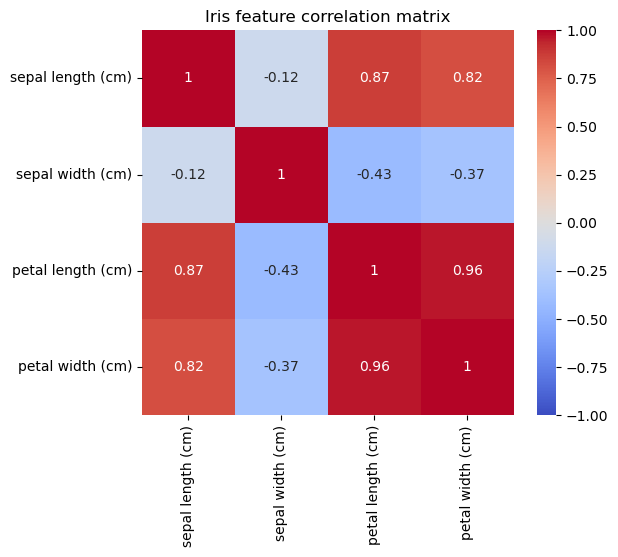

     sepal length (cm)  sepal width (cm)  petal length (cm)
0                  5.1               3.5                1.4
1                  4.9               3.0                1.4
2                  4.7               3.2                1.3
3                  4.6               3.1                1.5
4                  5.0               3.6                1.4
..                 ...               ...                ...
145                6.7               3.0                5.2
146                6.3               2.5                5.0
147                6.5               3.0                5.2
148                6.2               3.4                5.4
149                5.9               3.0                5.1

[150 rows x 3 columns]


In [180]:
from sklearn import datasets
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# 1. Compute correlation matrix
iris_data = datasets.load_iris(as_frame=True)
df = iris_data.data

corr_matrix = df.corr(method="pearson")
pd.set_option('display.max_columns', None)
pd.set_option("display.max_colwidth", None)
pd.set_option('display.width', 1000)
print(corr_matrix.round(3))

#Heat map
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap = "coolwarm", vmin=-1, vmax=1 )
plt.title("Iris feature correlation matrix")
plt.show()


# 2. Identify highly correlated features
## From the correlation matrix and heatmap we can see that petal length (cm) and  petal width (cm) are highly correlated featutes as the correlation is 0.96 which is close to 1.
## sepal length (cm), petal width (cm) and petal length (cm), sepal length (cm) are modorately correlated featuures.
# 3. Drop redundant features
## As per the correlation matrix we can drop either petal length (cm) or petal width (cm) from the list of features.
final_iris_df = df.drop(columns="petal width (cm)")
print(final_iris_df)

Q13. Custom Feature Transformation using apply()

Context: Real ML requires custom logic transformation.

Dataset: Titanic

Tasks:

1. Create age_group:
Child / Adult / Senior
2. Use .apply()
3. Compute survival rate per group
4. Interpret:
Which segment has highest survival likelihood

In [9]:
import seaborn as sns
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option("display.max_colwidth", None)
pd.set_option('display.width', 1000)

titanic_df = sns.load_dataset("titanic")
# titanic_df.info()

# we have some null values in age feature, so before creating a new feature we will impute the null values.
avg_age = round(titanic_df["age"].mean(), 1)
print(f"Imputing average age : {avg_age} for missing ages.")
titanic_df["age"] = titanic_df["age"].fillna(avg_age) 
print(f"Null values in age column: {titanic_df["age"].isna().sum()}")
print("Adding a new column age_group.")
titanic_df["age_group"] = titanic_df["age"].apply(lambda x: "Child" if x < 18 else "Adult" if x < 60 else "Senior")
print(f"Distinct values in column age_group is {titanic_df["age_group"].unique()}")

Imputing average age : 29.7 for missing ages.
Null values in age column: 0
Adding a new column age_group.
Distinct values in column age_group is ['Adult' 'Child' 'Senior']


Q14. Error Analysis Simulation (Model Evaluation Thinking)

Context: Understanding prediction errors is key in ML.

Tasks:

1. Generate 1000 random error values using NumPy
2. Compute:
Mean
Standard deviation
3. Identify outliers:
Using mean ± 2*std
4. Explain:
What high variance means in model performance

In [16]:
import numpy as np
np.random.seed(42)
error_df = np.random.normal(loc = 0, scale = 1, size = 1000)
# print(error_df)
mean_error = np.mean(error_df)
std_error = np.std(error_df)

print("Mean error:", round(mean_error, 4))
print("Standard deviation of errors:", round(std_error, 4))

lower_bound = mean_error - 2*std_error
upper_bound = mean_error + 2*std_error

print(f"Lowe bound is : {lower_bound} and upper bound is {upper_bound}.")

outliers = error_df[(error_df < lower_bound) | (error_df > upper_bound)]


print("Number of outliers:", len(outliers))
print("Outlier values:", outliers[:])





Mean error: 0.0193
Standard deviation of errors: 0.9787
Lowe bound is : -1.938120359672383 and upper bound is 1.9767844713170342.
Number of outliers: 44
Outlier values: [-1.95967012 -2.6197451  -1.98756891  2.46324211  2.19045563  2.72016917
  3.85273149  2.31465857  2.14394409 -2.02514259  2.1221562  -3.24126734
  2.13303337 -1.9520878   2.09238728  2.15318246  2.18980293 -2.12389572
  2.06074792 -2.03923218 -2.0674421  -2.30192116  3.07888081 -2.4716445
  2.0754008  -2.03812454 -2.21113531  2.27069286  2.44575198 -2.69688664
  2.5733598  -2.65096981 -2.07339023 -2.08192941  2.63238206  2.56008454
  2.29889812  2.45530014  2.01020454  2.52693243  2.16325472 -2.19880596
 -2.42387933 -2.04173487]


Q15. Business + ML Insight Problem (Tips Dataset)

Context: Convert data analysis into decision-making

Tasks:

1. Create:
tip_percentage
2. Group by:
day and time
3. Identify:
Highest revenue segment
4. Provide:
Recommendation for business strategy
How ML model can use this insight

In [32]:
import seaborn as sns

tips = sns.load_dataset("tips")

tips["tips_percentage"] = round((tips["tip"] * 100 )/ tips["total_bill"], 2)

highest_rev_seg = tips.groupby(["day", "time"])["total_bill"].sum().sort_values(ascending=False).head(1)

highest_rev_seg

C:\Users\WG241TS\AppData\Local\Temp\ipykernel_13356\2276728228.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  highest_rev_seg = tips.groupby(["day", "time"])["total_bill"].sum().sort_values(ascending=False).head(1)


day  time  
Sat  Dinner    1778.4
Name: total_bill, dtype: float64